# M(RT)$^2$

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

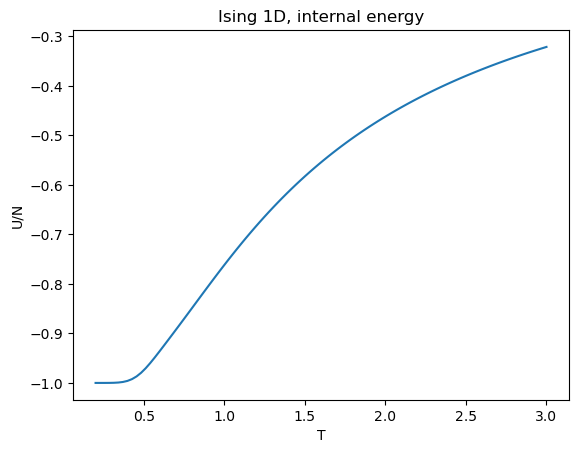

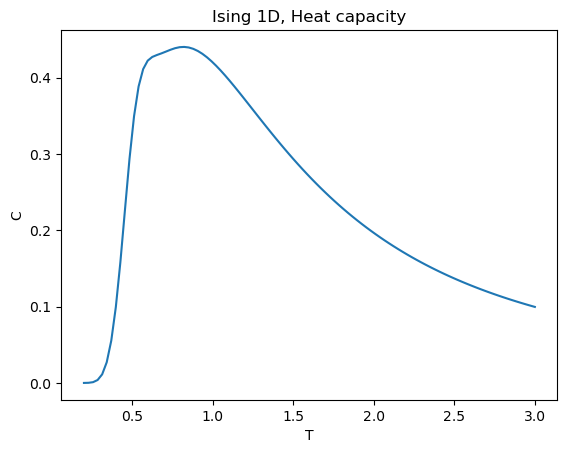

In [16]:
import numpy as np
import matplotlib.pyplot as plt
points=100
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )
plt.plot(T, e)
plt.title('Ising 1D, internal energy')
plt.xlabel('T')
plt.ylabel('U/N')
plt.show()

heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
plt.plot(T, heat)
plt.title('Ising 1D, Heat capacity')
plt.xlabel('T')
plt.ylabel('C')
plt.show()

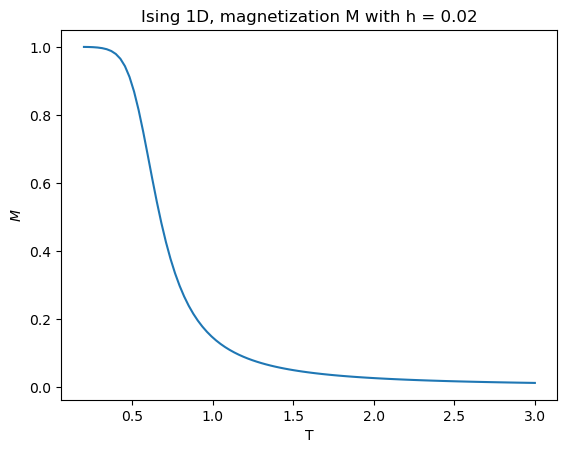

In [17]:
h=0.02 #external field
b = 1/T

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
plt.plot(T, M)
plt.title('Ising 1D, magnetization M with h = 0.02')
plt.xlabel('T')
plt.ylabel('$M$')
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_10353/759779259.py:5: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('$\chi$')


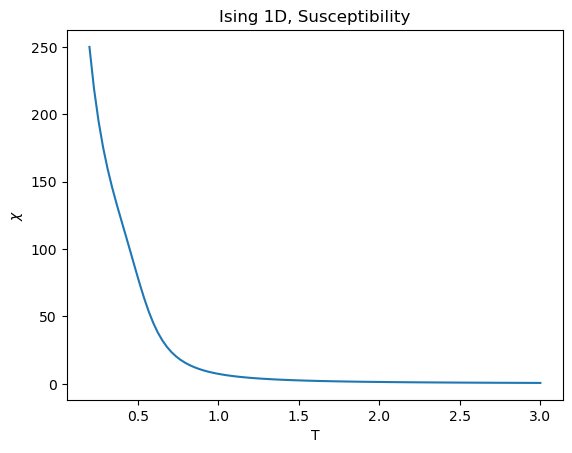

In [18]:
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)
plt.plot(T, X)
plt.title('Ising 1D, Susceptibility')
plt.xlabel('T')
plt.ylabel('$\chi$')
plt.show()

In [19]:

acc_mc=pd.read_csv('NSL_SIMULATOR/OUTPUT/MRT2/acceptance.dat',delimiter=r"\s+")
acc_mc

,#N_BLOCK:,ACCEPTANCE:
0,1,0.000011
1,2,0.000005
2,3,0.000004
3,4,0.000003
4,5,0.000002
...,...,...
595,16,0.668049
596,17,0.668053
597,18,0.668029
598,19,0.668003


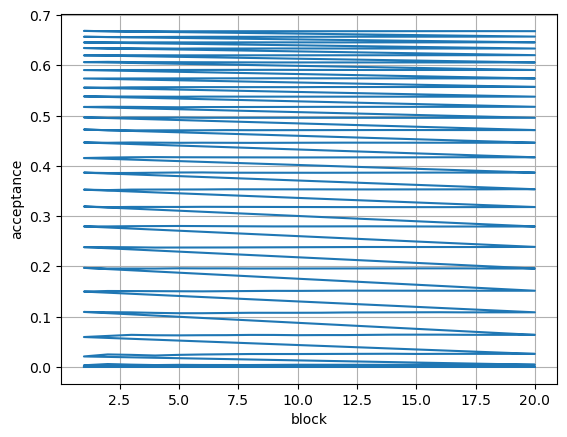

In [20]:
plt.plot(acc_mc['#N_BLOCK:'],acc_mc['ACCEPTANCE:'])
plt.xlabel('block')
plt.ylabel('acceptance')

plt.grid(True)

In [21]:
import os

os.listdir('NSL_SIMULATOR/OUTPUT/')

['specific_heat_temp1.1.dat',
 'magnetization_temp1.6.dat',
 'total_energy_temp1.6.dat',
 'magnetization_temp2.0.dat',
 'susceptibility_temp1.8.dat',
 'total_energy_temp2.5.dat',
 'susceptibility_temp0.6.dat',
 'magnetization_temp1.5.dat',
 'magnetization_temp0.7.dat',
 'specific_heat_temp0.7.dat',
 'susceptibility_temp2.5.dat',
 'susceptibility_temp1.3.dat',
 'specific_heat_temp1.3.dat',
 'total_energy_temp0.0.dat',
 'total_energy_temp2.1.dat',
 'specific_heat_temp0.3.dat',
 'magnetization_temp0.9.dat',
 'MRT2',
 'susceptibility_temp2.3.dat',
 'specific_heat_temp1.5.dat',
 'specific_heat_temp0.2.dat',
 'specific_heat_temp2.1.dat',
 'specific_heat_temp1.9.dat',
 'susceptibility_temp0.4.dat',
 'specific_heat_temp2.8.dat',
 'specific_heat_temp1.2.dat',
 'total_energy_temp0.2.dat',
 'total_energy_temp0.9.dat',
 'magnetization_temp1.7.dat',
 'magnetization_temp0.8.dat',
 'total_energy_temp1.3.dat',
 'output.dat',
 'seed.out',
 'total_energy_temp1.2.dat',
 'susceptibility_temp1.2.dat',
 'su

Text(0, 0.5, 'cv')

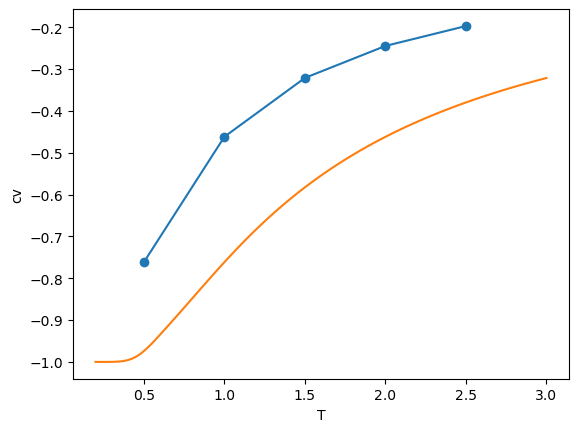

In [22]:
cvs=[]
cvs_err=[]
for i in range(1, 6):

    te=pd.read_csv(f'NSL_SIMULATOR/OUTPUT/total_energy_temp{i*0.5}.dat', delimiter=r'\s+',
                  skiprows=1,
                  names=['#block', 'actual_te', 'te_ave', 'error'] 
    )

    #print(cv)

    """plt.plot(cv['#block'], cv['actual_cv'], label='actual')
    plt.errorbar(x=cv['#block'], y=cv['cv_ave'], yerr=cv['error'], label='avg')
    plt.grid(True)
    plt.xlabel('#blocks')
    plt.ylabel('cv')

    plt.legend()

    plt.show()
    """
    cvs.append(te['te_ave'][len(te)-1])
    cvs_err.append(te['error'][len(te)-1])

    
    
plt.errorbar(x=[i*0.5 for i in range(1, 6)], y=cvs, yerr=cvs_err, marker='o')
plt.plot(T, e)

plt.xlabel('T')
plt.ylabel('cv')

Text(0, 0.5, 'cv')

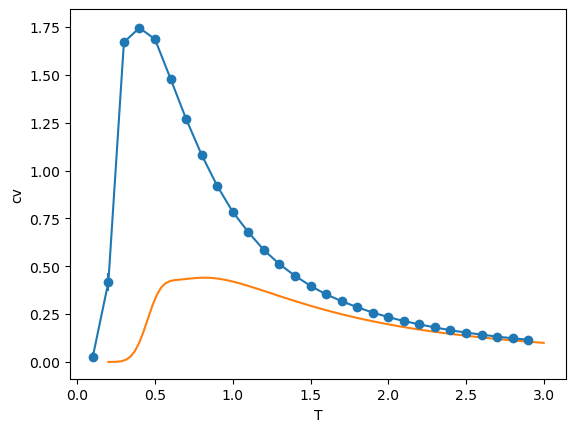

In [ ]:
gibbs=[]
gibbs_err=[]
for i in range(1, 30):

    cv=pd.read_csv(f'NSL_SIMULATOR/OUTPUT/specific_heat_temp{i/10}.dat', delimiter=r'\s+',
                  skiprows=1,
                  names=['#block', 'actual_cv', 'cv_ave', 'error'] 
    )

    #print(cv)

    """plt.plot(cv['#block'], cv['actual_cv'], label='actual')
    plt.errorbar(x=cv['#block'], y=cv['cv_ave'], yerr=cv['error'], label='avg')
    plt.grid(True)
    plt.xlabel('#blocks')
    plt.ylabel('cv')

    plt.legend()

    plt.show()
    """
    gibbs.append(cv['cv_ave'][len(cv)-1])
    gibbs_err.append(cv['error'][len(cv)-1])

    
mc=[]
mc_err=[]
for i in range(1, 30):

    cv=pd.read_csv(f'NSL_SIMULATOR/OUTPUT/specific_heat_temp{i/10}.dat', delimiter=r'\s+',
                  skiprows=1,
                  names=['#block', 'actual_cv', 'cv_ave', 'error'] 
    )

    #print(cv)

    """plt.plot(cv['#block'], cv['actual_cv'], label='actual')
    plt.errorbar(x=cv['#block'], y=cv['cv_ave'], yerr=cv['error'], label='avg')
    plt.grid(True)
    plt.xlabel('#blocks')
    plt.ylabel('cv')

    plt.legend()

    plt.show()
    """
    mc.append(cv['cv_ave'][len(cv)-1])
    mc_err.append(cv['error'][len(cv)-1])

    
    
    
plt.errorbar(x=[i*0.1 for i in range(1, 30)], y=gibbs, yerr=cvs_err, marker='o', label='Gibbs')
plt.plot(T, heat)

plt.xlabel('T')
plt.ylabel('cv')

Text(0, 0.5, 'cv')

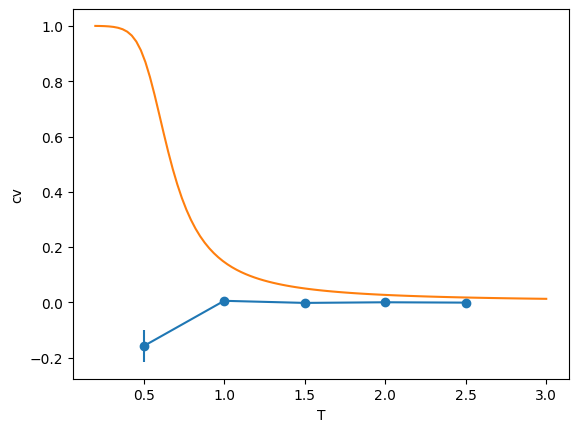

In [75]:
cvs=[]
cvs_err=[]
for i in range(1, 6):

    mag=pd.read_csv(f'NSL_SIMULATOR/OUTPUT/magnetization_temp{i*0.5}.dat', delimiter=r'\s+',
                  skiprows=1,
                  names=['#block', 'actual_mag', 'mag_ave', 'error'] 
    )

    #print(cv)
    """
    plt.plot(cv['#block'], cv['actual_cv'], label='actual')
    plt.errorbar(x=cv['#block'], y=cv['cv_ave'], yerr=cv['error'], label='avg')
    plt.grid(True)
    plt.xlabel('#blocks')
    plt.ylabel('magnetization')

    plt.legend()

    plt.show()
    """
    cvs.append(mag['mag_ave'][len(mag)-1])
    cvs_err.append(mag['error'][len(mag)-1])

    
    
plt.errorbar(x=[i*0.5 for i in range(1, 6)], y=cvs, yerr=cvs_err, marker='o')
plt.plot(T, M)

plt.xlabel('T')
plt.ylabel('cv')

In [55]:
cvs_err

[0.0572203, 0.00346474, 0.0014865, 0.000734297, 0.000609623]

Text(0, 0.5, 'cv')

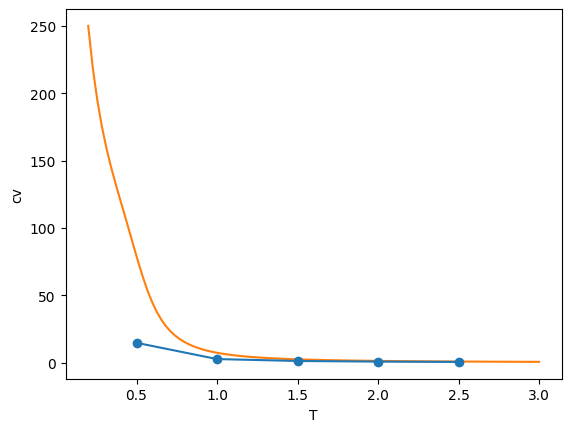

In [65]:
cvs=[]
cvs_err=[]
for i in range(1, 6):

    sus=pd.read_csv(f'NSL_SIMULATOR/OUTPUT/susceptibility_temp{i*0.5}.dat', delimiter=r'\s+',
                  skiprows=1,
                  names=['#block', 'actual_sus', 'sus_ave', 'error'] 
    )

    #print(cv)
    """
    plt.plot(cv['#block'], cv['actual_cv'], label='actual')
    plt.errorbar(x=cv['#block'], y=cv['cv_ave'], yerr=cv['error'], label='avg')
    plt.grid(True)
    plt.xlabel('#blocks')
    plt.ylabel('magnetization')

    plt.legend()

    plt.show()
    """
    cvs.append(sus['sus_ave'][len(sus)-1])
    cvs_err.append(sus['error'][len(sus)-1])

    
    
plt.errorbar(x=[i*0.5 for i in range(1, 6)], y=np.array(cvs), yerr=cvs_err, marker='o')
plt.plot(T, X)

plt.xlabel('T')
plt.ylabel('cv')